In [2]:
import matplotlib.pyplot as plt
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import rasterio

In [4]:
tif_file = "./data/week3/wmsMap_2024-11-23T1900.tif"
with rasterio.open(tif_file) as src:
    # Read the first band (Water Vapor channel)
    wv_band = src.read(1)
    # Get spatial extent for plotting: [left, right, bottom, top]
    bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    # Retrieve coordinate reference system if needed (typically EPSG:4326 for geostationary lat/lon grids)
    crs = src.crs

In [7]:
dublin_airport_lat = 55.372
dublin_airport_lon = -7.339

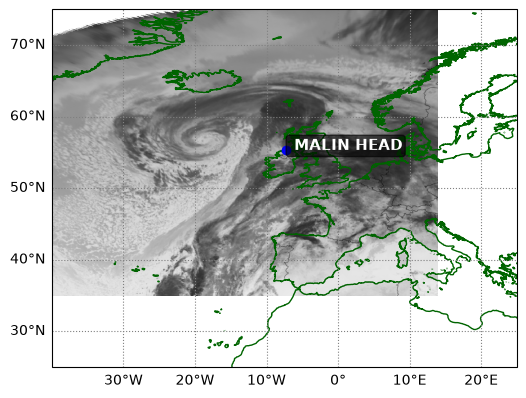

In [9]:
fig, ax = plt.subplots(
    figsize=(6, 6), subplot_kw={"projection": ccrs.PlateCarree()}
)

# Set spatial extent
# Extent format: [min_lon, max_lon, min_lat, max_lat]
ax.set_extent([-40.0, 25.0, 25.0, 75], crs=ccrs.PlateCarree())

# Display the satellite image as background
# Water Vapor channel is typically displayed inverted or in grayscale ('gray' or 'gray_r')
im = ax.imshow(
    wv_band,
    origin="upper",
    extent=extent,
    cmap="gray_r",
    transform=ccrs.PlateCarree(),
    vmin=1,
    vmax=255,
)

# Overlay Cartopy Features (Coastline & Borders)
ax.add_feature(
    cfeature.COASTLINE.with_scale("10m"), edgecolor="darkgreen", linewidth=1
)

# 6. Plot Dublin Airport location
ax.plot(
    dublin_airport_lon,
    dublin_airport_lat,
    'bo',
    transform=ccrs.PlateCarree()
)

# Add text label next to the marker
ax.text(
    dublin_airport_lon + 0.5,
    dublin_airport_lat,
    " MALIN HEAD",
    color="white",
    fontsize=11,
    fontweight="bold",
    transform=ccrs.PlateCarree(),
    bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.6),
)

# Add Gridlines, Labels, Colorbar & Title
gl = ax.gridlines(
    draw_labels=True, crs=ccrs.PlateCarree(), linestyle=":", color="gray"
)
gl.top_labels = False
gl.right_labels = False